<h2><b>计算机高等教育通用教材</b></h2>
<h2>机器学习 Machine learning</h2>
<hr>
<h5>第一部分：监督学习 supervised learning</h5>
<h5>第一章：分类 classification</h5>
<hr>
<h3><b>实验一：基于KNN（k-近邻）算法的分类预测实操</b></h3>
<hr>
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html'>查看knn源代码(sklearn)</a><br>
<a href='https://yuyiyang.me'>关于本实验教程作者</a>
<br>

> **适合人群** ：至少初中毕业，至少中考数学及格，【代数、一元一次、一元二次、二元一次函数、直角坐标系、初中简单统计学（平均值、方差）】等知识掌握扎实，python基础良好（熟练使用if-else，for，while，变量，列表，字典，集合，函数，类，有良好的分文件编程和oop编程习惯），学过numpy、pandas 和 matplotlib.pyplot库 并且至少能独立做出一个简单数据分析项目
<hr>

#### 第0步：测试python与虚拟环境

In [63]:
print("hello World")
import pip
pip.__version__

hello World


'24.0'

<hr><hr>

#### 第一步：import库 & 导入数据
<hr>

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [95]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

In [66]:
# 如果你是从外部csv文件导入数据的话（你的excel或者csv数据集在你的电脑里面存着了）， 你需要使用以下被注释的代码
# raw_df = pd.read_csv('./dataset/factory_data.csv')
# excel（表格） 或是 csv（逗号分隔数据）就会被自动转换为 pandas dataFrame

# 由于教材外置csv数据集不好，容易弄丢或者和教材代码文件混乱
# 我们这里使用 sklearn 库里面自带的 ‘鸢尾花数据集’进行示范
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'] #直接拉取出来的是纯数字，我们给数据集各列起个名字
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print(f'数据集大小: {df.shape}')
df.head()
# 使用 pandas中的 dataFrame.head()函数，显示前5行看看

数据集大小: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<hr><hr>

#### 第二步：查看数据的基本信息
<hr>

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sepal_length  150 non-null    float64 
 1   sepal_width   150 non-null    float64 
 2   petal_length  150 non-null    float64 
 3   petal_width   150 non-null    float64 
 4   species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB


In [68]:
df.describe()
# 看看数值

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [69]:
df.isna().sum().sort_values()
# 看看缺失值
# 其实上面info()那里可以看到每列都是150个non-null值，就可以不用检查缺失值了

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [70]:
df['species'].value_counts()
# 看看 species 有几种（有几种鸢尾花）

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

<hr><hr>

#### 第三步：探索性数据分析
<hr>

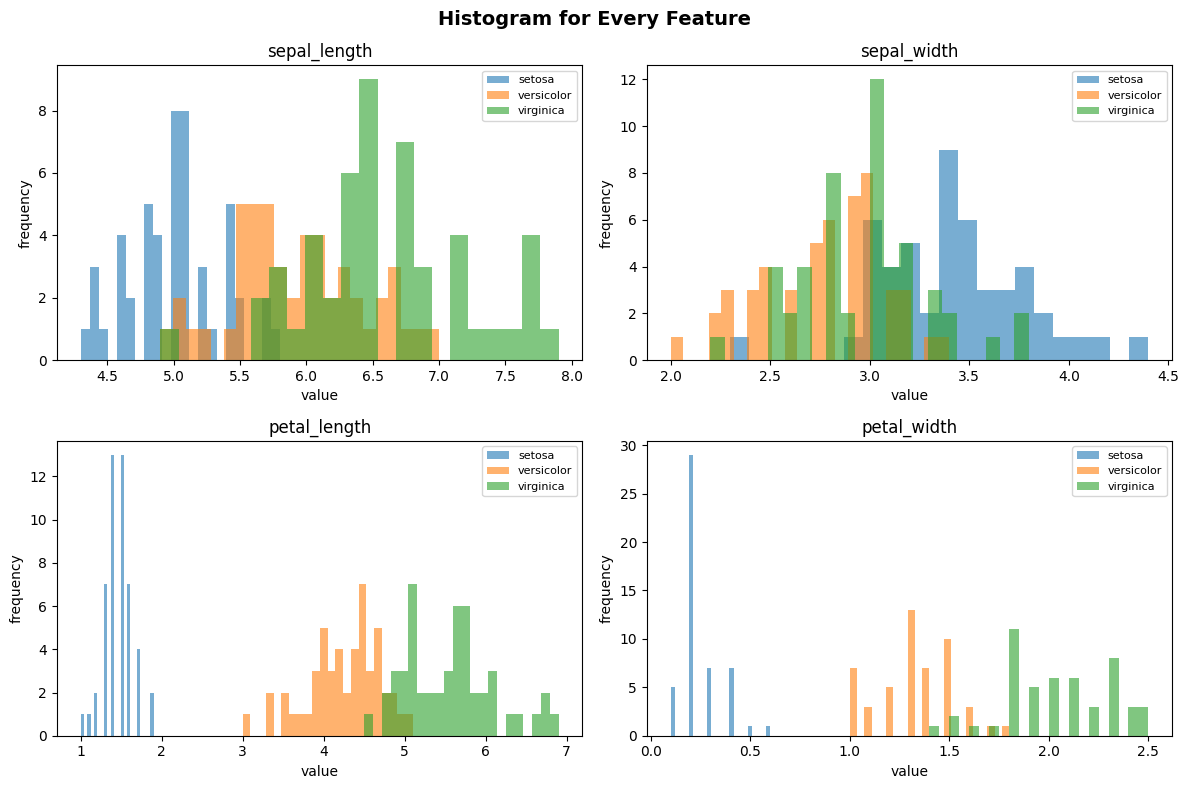

In [71]:
# histogram图，查看每种花在每个特征中的数据分布，比如setosa花的花瓣(petal)长度明显低于其他两种花（见左下图）
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Histogram for Every Feature', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), feature_cols):
    for species in df['species'].unique():
        data = df[df['species'] == species][col]
        ax.hist(data, alpha=0.6, label=species, bins=22)
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.set_xlabel('value')
    ax.set_ylabel('frequency')

plt.tight_layout()
plt.show()

<hr><hr>

#### 第四步：特征工程
<hr>

##### 众所周知，有效数据越多模型越强，我们这里尝试一下多加两列，给模型不一样的看数据的角度
##### 这种增加数据或是强化特定数据的行为，被称为 特征工程（feature engineering） 

In [72]:
# 新增两列数据（花瓣/花萼面积近似）（面积=长*宽）:
df['petal_area'] = df['petal_length'] * df['petal_width']
df['sepal_area'] = df['sepal_length'] * df['sepal_width']
df

# 如果模型只能看到 length（长） 和 width（宽），它需要自己“学会”乘法关系；
# 如果你直接给它 area（面积），相当于 帮模型提前计算了一个可能有意义的模式。


##### 但是也要小心，列数（维度）加的太多了容易出现 “维度诅咒”，就是：高维空间中距离计算公式会突然变得不好使。
##### 大致原因是因为维度【特征/列数】太多了之后，在特征空间中的距离容易被平均，“我到我最近的邻居（和我最相似的人）的距离” 和 “我到我最远的邻居（和我最不同的人）的距离” 变得差不多；
##### 比如我们要分类15亿人，然后我们给了模型每个人的1万个特征（列）（包括：身高，体重，年龄，..., 弹拨类乐器能力, 游戏反应能力，电脑修理能力，...........），
##### 一个人不太可能既是古筝大师又是射击游戏职业选手，在选取的特征多了之后，每个人都在一些方面有特长，在一些地方有缺陷，
##### 这会让模型觉得每个人都独一无二、大不相同，每个人的点周围很难有同类，每个人所在的点到另一个人的点的欧式距离都几乎差不多。
##### 模型会觉得：“这我怎么学，所有人都几乎'完全'不一样，我怎么把这15亿人分成5类， 我完全找不出来你们这3亿人有什么共同点。【苦笑】”

##### 对于一些距离判定的分类或聚类模型（如knn和kmeans），“维度诅咒” 是真诅咒 ，因为模型分不出类了。

##### 之后在 k-means实验中我们会学习如何使用 PCA（主成分分析）和 NMF 等方法进行 “智能降维” （去掉一些列，同时保留里面的信息），而不是直接删除那些列

##### 所以说：如何使用特征工程创造一些“有用”（比如掰开揉碎的信息，不同的观察角度）的特征很重要，如果随便加减乘除搞出一堆新的列，可能就会陷入：“维度诅咒+本身也没啥信息可学” 的困境

,sepal_length,sepal_width,petal_length,petal_width,species,petal_area,sepal_area
0,5.1,3.5,1.4,0.2,setosa,0.28,17.85
1,4.9,3.0,1.4,0.2,setosa,0.28,14.70
2,4.7,3.2,1.3,0.2,setosa,0.26,15.04
3,4.6,3.1,1.5,0.2,setosa,0.30,14.26
4,5.0,3.6,1.4,0.2,setosa,0.28,18.00
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,11.96,20.10
146,6.3,2.5,5.0,1.9,virginica,9.50,15.75
147,6.5,3.0,5.2,2.0,virginica,10.40,19.50
148,6.2,3.4,5.4,2.3,virginica,12.42,21.08


<hr>

#### 第五步：‘测试集’和‘训练-验证集’的分割
<hr>

In [73]:
SEED = 42 #留个种子，制造伪随机而不是真随机
# 如果真随机的话就无法重复做一样的实验得出一样的结果了，万一被人质疑你的结论瞎编，你都没有证据反驳（你无法再做一遍实验得出同样的结果）

X = df.drop(columns=['species']) # X 就是除了species以外的所有列，我们用它来预测 y
y = df['species']  # y 就是预测的结果，我们根据 X 中的各种特征来预测 species（花的种类）(y)


# 我们把数据划分，80%作为学习的（训练/验证集），20%作为最后的考试（测试集）来判断模型学的到底怎么样
# 为什么要分出20%专门用来考试呢？难道不浪费数据吗？
# 因为我们不想让模型考试的题目全是平时练过的‘原题’。
# 如果你是一个老师，肯定也不希望同学靠着刷题的记忆直接拿高分对吧，而是测试学生是否真正掌握和理解了这些知识点
# 模型也是这样，我们期望它 **泛化** ， 也就是在没见过的题目上也能用刚才拟合完的函数去套并且成功拿高分

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% 作为 test
    random_state=SEED,
    stratify=y           # 按类别比例分层, 避免一堆（训练数据）全是x花，另一堆（测试数据）全是y花
)

print('数据集大小：')
print(f'训练-验证集: {X_train_val.shape}, 测试集: {X_test.shape}')

数据集大小：
训练-验证集: (120, 6), 测试集: (30, 6)


<hr><hr>

#### 第六步：标准化 + Pipeline + KFold 交叉验证
<hr>

In [74]:
# 什么是pipeline?
# Pipeline（管道）会自动把里面的步骤打包，就可以进行重复实验。但是最关键的不是这个
# 最关键的是：
# 在监督学习中，我们需要测试集来验证模型学的好不好，
# 然后如果我们对整个dataFrame做（比如 把（数字）替换为（总平均值-数字））一类的操作，那就完了：
# 模型很精的，它能靠平均值和曾经学过的训练集数据推算出来测试集的大致答案，这叫做 **数据泄漏**
# 所以我们需要保证 遇到这类操作， 训练集上和测试集上要完全分开，比如 把（测试集数字）替换为（测试集平均值-测试集数字），
# pipeline提供了一个很好的隔离效果，严格确保 train_test_split（分开） 先，然后再做一些数值操作，杜绝了人犯傻搞错，或者是储存混乱导致数据泄露的问题

def build_pipeline(k=5):
    """构建 StandardScaler + KNN Pipeline"""
    return Pipeline([
        ('scaler', StandardScaler()),   # Step 1: 标准化
        ('knn',   KNeighborsClassifier(n_neighbors=k))  # Step 2: KNN 分类
    ])

print('Pipeline 结构:')
print(build_pipeline())


# step 1 是标准化 standard scaler，这是一个非常重要的统计学和AI机器学习知识：
# 简单来说，就是它让每个数字变成了 z-score（z分数）， z-score =（自己-这一堆的平均值）/这一堆的标准差
# 举个例子： 小霖70分，小清75分，小熙80分，小念85分，嘉豪90分， 嘉豪的z-score是 (90-80)/7.071 = 1.414， 意味着他领先了平均值1.414个标准差。
# 这让模型去理解：每个数据在所有数据中怎么样（领先或落后多少），而不是死盯着 **绝对数值**


# 这里的step2 就是模型，sklearn这个库已经帮你写好了训练过程代码，你调用一个函数就行，不用自己写

Pipeline 结构:
Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])


In [75]:
# min-max又叫归一化，可以把一组数据全部缩放进一定数值区间里面，比如 【0，1，100】 --变成--> 【0，0.01，1】（比如缩小到0-1区间）

# 一般来讲，knn是需要min-max的，因为本质上knn是把这些数据点放入 多维“直角坐标系” ， 然后根据距离进行分组。 所以需要 x轴 和 y轴 甚至更多轴 都有一样的数值跨度。
# 比如我们在把人进行分类的时候，某人 身高(y轴)180cm + 体重(x轴)80kg。如果有另一个 身高80m + 体重5kg的人，那他们的y轴（身高）的差距就被高估了。
# 180cm 和 80cm的差距纯数字有 100， 但是其实差距是（幼儿园学生 和 成年人 的差距）
# 80 kg - 5 kg 在纯数字上只有 75，实际上差距更大（刚出生 和 成年人 的差距）
# 这时候我们就需要 把身高【（0到200）-变成-> (0到1)】，体重【（0到100）-变成-> (0到1)】，
# 模型就不会过度关注身高了

# 但是这里我们使用的是“鸢尾花数据集”，大家的单位都是cm厘米，就不用了min-max了。而是选用standard-scaler。
# 他们都是数据处理（让模型不再被极端数据影响）的方式，一般选一种就好

In [76]:
##############################################################
# 还记得我们把数据分成了 train_val 和 test 吗？
# test 是期末考试，压箱底的，现在先不动它。
# 那 train_val 这80%的数据，我们怎么用？

# 最简单的做法：直接把 train_val 再切一刀，比如 70%训练，10%验证。
# 但是这有个问题：你的模型表现好不好，取决于你"运气好不好"——
# 万一那10%验证集恰好全是"简单题"，你以为模型学得很好，其实只是碰巧。
# 万一那10%全是"偏题难题"，你以为模型很烂，其实只是运气不好。
# 总之，验证集只有一份，结论不够可信。

# KFold 的思路是：与其赌一次，不如考5次，取平均。
# 具体做法：把 train_val 平均切成5份（fold）
# 第1次：用第2、3、4、5份训练，第1份验证
# 第2次：用第1、3、4、5份训练，第2份验证
# 第3次：用第1、2、4、5份训练，第3份验证
# 第4次：用第1、2、3、5份训练，第4份验证
# 第5次：用第1、2、3、4份训练，第5份验证
# 每一份都当过一次验证集，最后把5次的accuracy取平均，结论更可靠。

# 图示（5折）：
# Fold 1: [验证] [训练] [训练] [训练] [训练]
# Fold 2: [训练] [验证] [训练] [训练] [训练]
# Fold 3: [训练] [训练] [验证] [训练] [训练]
# Fold 4: [训练] [训练] [训练] [验证] [训练]
# Fold 5: [训练] [训练] [训练] [训练] [验证]
# 最终得分 = 5次验证 accuracy 的平均值

# 这就好比：期末考试前，老师出了5套模拟卷，
# 每套卷子来自不同的题库，你5套都做了。
# 5套的平均分才能真实反映你的水平，而不是靠一套模拟卷的运气。

# 注意：KFold 整个过程都在 train_val 里面进行，test 依然压箱底，纹丝不动。
# KFold 结束后我们得到的是"这个模型/这组超参数大概有多强"的一个估计，用于排列组合，选出最好的超参数等
# 最终还是要用 最好的超参数 和 全部的数据 train_val 重新 fit 一次，再拿 test 做最后的考试。
####################################################################

k_values = list(range(1, 26))  # 试 k=1, 2, 3, ..., 25
kfold_mean_scores = []
kfold_std_scores  = []

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

In [77]:
####################################################################
# 什么是超参数（Hyperparameter）？
# 
# 模型训练时自己学出来的东西叫"参数"（parameter），比如KNN里每个点的权重。
# 而超参数是你在训练"之前"就要手动设置好的配置项，模型自己学不出来，需要你来拍板。
# 
# 拿KNN举例：
#   k=1  → 只看最近的1个邻居来投票，非常容易被噪声带偏（一个离群点就能左右结果）
#   k=3  → 看最近3个邻居投票，稳一点
#   k=50 → 看50个邻居，太多了，反而把不相关的点也算进去了，什么都影响不了，模型变得迟钝
# 
# 
# 那怎么选一个合适的 k？
# 凭感觉？不行，太不严谨。
# 一个一个手动试然后看结果？可以，但是很蠢，而且容易不小心用test集来挑，又变成数据泄漏了。
# 
# 正确做法：用 KFold 来自动帮你试每一个 k，
# 每个 k 都跑一遍5折交叉验证，得到5折平均accuracy，
# 哪个 k 的平均accuracy最高，就选哪个。
# 全程不碰 test 集，选出最好的 k 之后才去 test 上做最终考试。
# 
# 这个"系统性地试不同超参数，用交叉验证评估，自动找最优组合"的过程
# 就叫做 超参数调优（Hyperparameter Tuning）。
####################################################################

print('开始 KFold 超参数搜索...\n')

for k in k_values:
    pipeline = build_pipeline(k=k)
    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_val)):
        # kf.split 每次给你两组下标：哪些行做训练，哪些行做验证
        X_fold_train = X_train_val.iloc[train_idx]
        X_fold_val   = X_train_val.iloc[val_idx]
        y_fold_train = y_train_val.iloc[train_idx]
        y_fold_val   = y_train_val.iloc[val_idx]

        # Pipeline 在这里的作用体现出来了：
        # scaler 的 fit 只看 X_fold_train，不会看到 X_fold_val 的任何信息
        # 然后用 fit 出来的 scaler 去 transform X_fold_val
        # 这样每一折的验证集都是"干净的"，没有被泄漏过
        pipeline.fit(X_fold_train, y_fold_train)
        score = pipeline.score(X_fold_val, y_fold_val)
        fold_scores.append(score)

    kfold_mean_scores.append(np.mean(fold_scores))
    kfold_std_scores.append(np.std(fold_scores))
    print(f'  k={k:>2d}:  5折平均 准确率 = {np.mean(fold_scores):.4f}  ± {np.std(fold_scores):.4f}')

开始 KFold 超参数搜索...

  k= 1:  5折平均 准确率 = 0.9417  ± 0.0425
  k= 2:  5折平均 准确率 = 0.9250  ± 0.0486
  k= 3:  5折平均 准确率 = 0.9500  ± 0.0312
  k= 4:  5折平均 准确率 = 0.9667  ± 0.0312
  k= 5:  5折平均 准确率 = 0.9583  ± 0.0373
  k= 6:  5折平均 准确率 = 0.9500  ± 0.0312
  k= 7:  5折平均 准确率 = 0.9500  ± 0.0408
  k= 8:  5折平均 准确率 = 0.9417  ± 0.0333
  k= 9:  5折平均 准确率 = 0.9417  ± 0.0333
  k=10:  5折平均 准确率 = 0.9583  ± 0.0373
  k=11:  5折平均 准确率 = 0.9500  ± 0.0408
  k=12:  5折平均 准确率 = 0.9417  ± 0.0333
  k=13:  5折平均 准确率 = 0.9417  ± 0.0333
  k=14:  5折平均 准确率 = 0.9333  ± 0.0333
  k=15:  5折平均 准确率 = 0.9250  ± 0.0167
  k=16:  5折平均 准确率 = 0.9333  ± 0.0333
  k=17:  5折平均 准确率 = 0.9333  ± 0.0333
  k=18:  5折平均 准确率 = 0.9250  ± 0.0312
  k=19:  5折平均 准确率 = 0.9167  ± 0.0456
  k=20:  5折平均 准确率 = 0.9000  ± 0.0624
  k=21:  5折平均 准确率 = 0.9000  ± 0.0624
  k=22:  5折平均 准确率 = 0.9000  ± 0.0624
  k=23:  5折平均 准确率 = 0.8833  ± 0.0553
  k=24:  5折平均 准确率 = 0.8750  ± 0.0791
  k=25:  5折平均 准确率 = 0.8833  ± 0.0667


In [78]:
# 找出最优的 k
best_k = k_values[np.argmax(kfold_mean_scores)]
best_score = max(kfold_mean_scores)
print(f'\n 最优 k = {best_k}，对应5折平均 准确率 = {best_score:.4f}')


 最优 k = 4，对应5折平均 准确率 = 0.9667


In [85]:
import matplotlib.font_manager as fm

zh_fonts = [f.name for f in fm.fontManager.ttflist 
            if any(kw in f.name for kw in ['Hei', 'Song', 'CJK', 'Chinese', 'SC', 'TC', 'Gothic'])]
print(sorted(set(zh_fonts)))

['Noto Sans CJK JP', 'Noto Sans Gothic', 'Noto Serif CJK JP', 'URW Gothic']


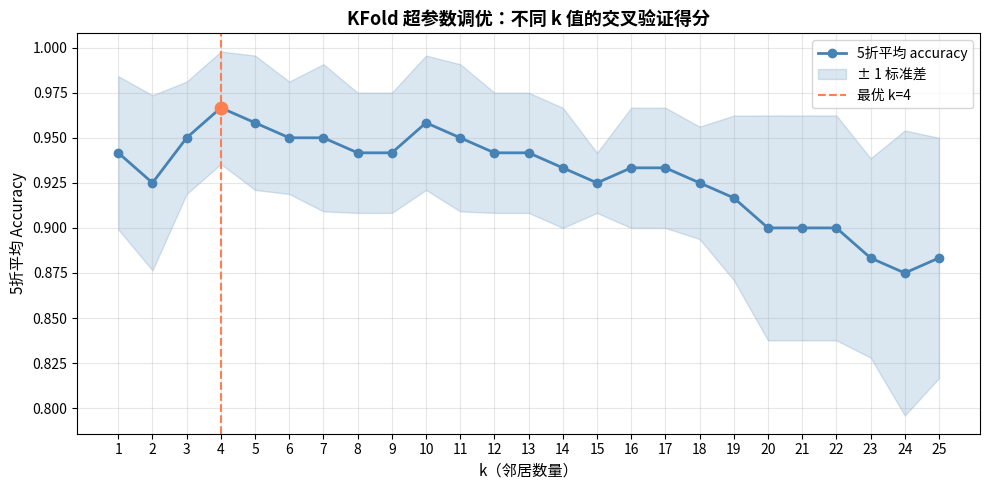

In [87]:
# font family指定一下才能显示中文，这里就不下载中文包了，日语包也能显示中文
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False

# 可视化：不同 k 对应的 KFold 平均 accuracy
# 这张图很经典，能清晰看到 k 从小到大时，模型从"过拟合"到"欠拟合"的变化趋势
plt.figure(figsize=(10, 5))
plt.plot(k_values, kfold_mean_scores, 'o-', color='steelblue', linewidth=2, label='5折平均 accuracy')
plt.fill_between(
    k_values,
    np.array(kfold_mean_scores) - np.array(kfold_std_scores),
    np.array(kfold_mean_scores) + np.array(kfold_std_scores),
    alpha=0.2, color='steelblue', label='± 1 标准差'
)

# fill_between 画出来的阴影区域代表5折之间的波动范围
# 阴影越宽说明模型越不稳定（不同折之间差距大），阴影越窄说明越稳定可靠
plt.axvline(x=best_k, color='coral', linestyle='--', linewidth=1.5, label=f'最优 k={best_k}')
plt.scatter([best_k], [best_score], color='coral', s=80, zorder=5)
plt.xlabel('k（邻居数量）', fontsize=11)
plt.ylabel('5折平均 Accuracy', fontsize=11)
plt.title('KFold 超参数调优：不同 k 值的交叉验证得分', fontsize=13, fontweight='bold')
plt.xticks(k_values)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<hr><hr>

#### 第七步：用最优超参数重新训练，在 test 集上做<b>最终评估</b>
<hr>

In [80]:
##############################################################
# KFold 只是帮我们"选"出了最好的 k，
# 但那5折训练出来的模型每个都只用了4/5的 train_val 数据，
# 相当于你5套模拟卷都做完了，现在正式考试之前，
# 应该把5套模拟卷的知识全部复习一遍（用全部 train_val 重新 fit），
# 而不是直接拿其中一套模拟卷做完的状态去考试。
##############################################################

final_pipeline = build_pipeline(k=best_k)
final_pipeline.fit(X_train_val, y_train_val)
# 这一次 scaler 和 KNN 都是在完整的 train_val 上训练的

y_pred = final_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f'最终模型（k={best_k}）在 test 集上的 Accuracy：{test_accuracy:.4f}')

最终模型（k=4）在 test 集上的 Accuracy：0.9333


In [81]:
# 基线模型（Baseline）对比
# 做完自己的模型，一定要和"什么都不学的傻模型"比一下
# 如果你辛辛苦苦训练的KNN，结果还不如"每次都猜最多的那个类"，那模型基本上是白做了
# DummyClassifier(strategy='most_frequent') 就是这个"每次都猜最常见类别"的傻模型

baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('dummy', DummyClassifier(strategy='most_frequent', random_state=SEED))
])
baseline.fit(X_train_val, y_train_val)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f'基线模型（啥都不训练）在 test 集上的 Accuracy：{baseline_acc:.4f}')
print(f'KNN 提升了：{test_accuracy - baseline_acc:+.4f}')

基线模型（啥都不训练）在 test 集上的 Accuracy：0.3333
KNN 提升了：+0.6000


In [82]:
# Classification Report：比 accuracy 更细致的成绩单
# accuracy 只告诉你"你答对了多少题"，但不告诉你"哪种花分错了"
# classification_report 会给出每个类别的：
#   precision（精确率）：你说是A花的里面，真的是A花的有多少
#   recall（召回率）：   所有真正的A花里面，你认出了多少
#   f1-score：          precision 和 recall 的调和平均，综合指标

# 这里的这个 f1分数至关重要，因为模型容易偷懒
# 比如在预测 “该短信是否属于金融诈骗” 的二分类任务中，由于 “金融诈骗” 发生概率小，大部分短信都是正常的验证码啥的，模型可能直接摆烂。
# 因为：模型啥都不干，直接说所有短信都没问题，它的精确率都很高。由于99%的短信是真的没问题，模型直接说 “所有短信都没问题” 的这句话的精确率perc就已经达到了 99%。
# 像这个场景中就不能只用 精确率作为模型的分数，而是要添加 召回率 recall 来评判。
# 另外有些场景就是反过来的，我们不能只用 召回率recall，要用 精确率perc；

# 由于 不能纯靠 精确率perc 或者 召回率recall 来进行计算，而 F1分数 作为两者的混合体，所以我们经常使用它来做一些客观评判

print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



#### F1 分数 的数学公式是：
$$ F_1 = 2 \times \frac{\text{precision精确率} \times \text{recall召回率}}{\text{precision精确率} + \text{recall召回率}} $$

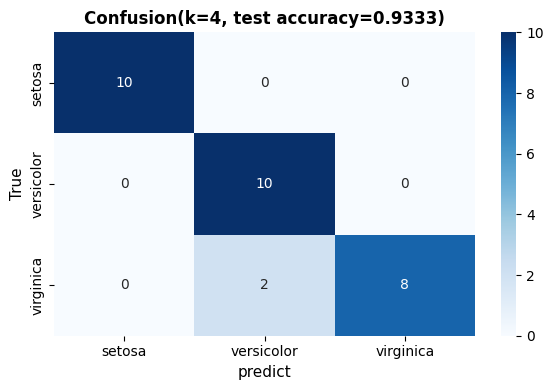

In [83]:
# 混淆矩阵（Confusion Matrix）
# 行 = 真实类别，列 = 预测类别
# 对角线上的数字 = 猜对了的
# 对角线外的数字 = 猜错了的，而且能看出"把哪种花错认成了哪种花"
# 比如 versicolor 和 virginica 长得比较像，经常互相误判，混淆矩阵能直接看出来.

# 这是一个统计学小妙招
# *一般在二分类任务的时候用这个会更多一些
# 可以区分 “假阳”，“假阴”，“真阳”，真阴”，
# 假阳 在统计学中被称为 type I error（一类错误），意思是实际上牌没什么问题（偏向零假设），但是模型硬是验牌验出问题来了（拒绝了零假设，使 备择假设 成立）
# 假阴 在统计学中被称为 type II error（二类错误），意思是实际上牌有问题（需要拒绝零假设），但是模型硬是没看出来（没有拒绝零假设）

# 这个鸢尾花预测 不是 二分类，它有三个结果：setosa花、versicolor花 和 virginica花

cm = confusion_matrix(y_test, y_pred, labels=final_pipeline.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=final_pipeline.classes_,
    yticklabels=final_pipeline.classes_
)
plt.xlabel('predict', fontsize=11)
plt.ylabel('True', fontsize=11)
plt.title(f'Confusion(k={best_k}, test accuracy={test_accuracy:.4f})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### 第八步：【拓展提高】knn核心算法拆解

In [88]:
##############################################################
# KNN 内部是怎么工作的？
# 
# 我们一直在用 sklearn 的 KNeighborsClassifier，
# 一行 .fit() 一行 .predict() 就出结果了，但它内部到底在干什么？
# 
# KNN 的核心思路极其简单，简单到令人发指：
# "你想知道这朵花是什么种类？
#  去找训练集里和它最像的 k 朵花，看看它们是什么种类，少数服从多数，投票决定。"
# 
# 具体步骤：
# 第一步：计算"距离" ── 这朵新花和训练集里每一朵花有多像（多近）？
# 第二步：排序 ── 从近到远排列所有训练集的花
# 第三步：投票 ── 取最近的 k 朵，看看它们的 species，哪个类别票数最多就输出哪个
# 
# 距离怎么算？最常用的是 欧式距离（Euclidean Distance）：
# 就是你初中学的勾股定理，只不过从2维推广到了多维
# 
# 2维（x, y）：  distance = sqrt( (x1-x2)² + (y1-y2)² )
# 4维（4个特征）：distance = sqrt( (a1-a2)² + (b1-b2)² + (c1-c2)² + (d1-d2)² )
# 
# 举个例子：
# 新花：[5.0, 3.0, 1.5, 0.3]（sepal_length, sepal_width, petal_length, petal_width）
# 训练集某花：[4.8, 3.1, 1.6, 0.2]
# 距离 = sqrt( (5.0-4.8)² + (3.0-3.1)² + (1.5-1.6)² + (0.3-0.2)² )
#       = sqrt( 0.04 + 0.01 + 0.01 + 0.01 )
#       = sqrt( 0.07 )
#       ≈ 0.265
# 
# 这个距离越小，说明两朵花越相似。
# KNN 就是对训练集里的每一朵花都算一遍这个距离，然后找最小的 k 个。
##############################################################

In [89]:
# 我们手动实现一遍 KNN 的预测过程，不用任何封装，逻辑完全裸奔
# 用标准化之后的数据（和 pipeline 里一致）

# 先把标准化做好（模拟 pipeline 里 scaler 的效果）
scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)  # 只在 train_val 上 fit
X_test_scaled      = scaler.transform(X_test)           # test 用 train_val 的均值/标准差来 transform

# 取 test 集的第一朵花，试着手动预测它的种类
test_flower = X_test_scaled[0]        # 这朵花的4个标准化后的特征值
true_label  = y_test.iloc[0]          # 它真实的种类（答案）
print(f'待预测的花（标准化后）：{test_flower}')
print(f'真实种类：{true_label}')

待预测的花（标准化后）：[-1.72156775 -0.10821272 -1.40250384 -1.32327558 -1.17384658 -1.32261875]
真实种类：setosa


In [90]:
# 第一步：计算这朵花和训练集里每一朵花的欧式距离

distances = []  # 用来存每朵训练集的花和它的距离

for i in range(len(X_train_val_scaled)):
    train_flower = X_train_val_scaled[i]

    # 欧式距离：每个维度差值的平方，全部加起来，开根号
    diff = test_flower - train_flower          # 每个特征的差值，是个长度为4的数组
    diff_squared = diff ** 2                   # 每个差值平方
    sum_of_squares = diff_squared.sum()        # 加总
    distance = sum_of_squares ** 0.5           # 开根号（等价于 np.sqrt，这里故意不用函数）

    distances.append(distance)

distances = np.array(distances)
print(f'共计算了 {len(distances)} 个距离（训练集共 {len(X_train_val_scaled)} 朵花）')
print(f'最小距离：{distances.min():.4f}，最大距离：{distances.max():.4f}')

共计算了 120 个距离（训练集共 120 朵花）
最小距离：0.2303，最大距离：8.1257


In [91]:
# 第二步：从小到大排序，找出最近的 k 朵花

K = best_k  # 用之前 KFold 调优找出来的最优 k

sorted_indices = np.argsort(distances)   # argsort 返回的是"排序后对应的原始下标"
# 比如 distances = [0.5, 0.1, 0.8]，argsort 返回 [1, 0, 2]，意思是第1个最小，第0个第二小，第2个最大

top_k_indices   = sorted_indices[:K]     # 取最近的 k 个的下标
top_k_distances = distances[top_k_indices]
top_k_labels    = y_train_val.iloc[top_k_indices].values  # 这 k 朵花的真实种类

print(f'\n最近的 {K} 朵花：')
for rank, (idx, dist, label) in enumerate(zip(top_k_indices, top_k_distances, top_k_labels), 1):
    print(f'  第{rank}近：训练集第{idx}朵花，距离={dist:.4f}，种类={label}')


最近的 4 朵花：
  第1近：训练集第93朵花，距离=0.2303，种类=setosa
  第2近：训练集第0朵花，距离=0.2639，种类=setosa
  第3近：训练集第119朵花，距离=0.4631，种类=setosa
  第4近：训练集第49朵花，距离=0.6085，种类=setosa


In [92]:
# 第三步：投票，少数服从多数

# 统计 k 个邻居里每个种类出现了几次
votes = {}   # 字典：{种类名: 票数}

for label in top_k_labels:
    if label not in votes:
        votes[label] = 0
    votes[label] += 1

print(f'投票结果：{votes}')

# 找票数最多的种类
predicted_label = max(votes, key=votes.get)
# max(..., key=votes.get) 的意思是：
# 遍历 votes 字典的所有 key（种类名），找出让 votes.get(key) 最大的那个 key

print(f'\n手动 KNN 预测结果：{predicted_label}')
print(f'真实种类：        {true_label}')
print(f'预测{"正确" if predicted_label == true_label else "错误"}')



投票结果：{'setosa': 4}

手动 KNN 预测结果：setosa
真实种类：        setosa
预测正确


In [93]:
# 顺便验证一下：sklearn 的 KNN 对同一朵花的预测结果是否一致？
sklearn_pred = final_pipeline.predict(X_test.iloc[[0]])[0]
print(f'\nsklearn KNN 预测结果：{sklearn_pred}')
print(f'手搓 KNN 预测结果：  {predicted_label}')
print(f'两者{"一致" if sklearn_pred == predicted_label else "不一致，检查一下哪里算错了"}')


sklearn KNN 预测结果：setosa
手搓 KNN 预测结果：  setosa
两者一致


In [94]:
##############################################################
# 为什么 KNN 没有"训练过程"？
# 
# 你可能注意到了：.fit() 之后 KNN 其实什么都没算，
# 它只是把训练数据"记住"（存进内存），
# 等你 .predict() 的时候才开始计算距离。
# 
# 这和大多数模型完全不同。
# 比如线性回归：训练时就把所有参数算好了，预测时直接套公式，很快。
# KNN：训练时什么都不做，预测时才开始算距离，数据越多预测越慢。
# 
# 这种"训练时啥都不干，预测时再算"的模型，
# 学术上叫做 惰性学习（Lazy Learning）或 基于实例的学习（Instance-based Learning）。
# 
# 所以 KNN 有个天然缺陷：
# 数据量大了之后，每次预测都要和所有训练数据算一遍距离，非常慢。
# 比如训练集有100万条数据，预测一个新样本就要算100万次欧式距离。
# 实际工程中遇到大数据集，一般不会直接用 KNN，或者会用 KD-Tree 等数据结构来加速。
##############################################################

#### 总结

| 步骤 | 操作 | 作用 |
|------|------|------|
| 获取基本数据信息 | pandas | 理解大致有几行几列，以及缺了些什么 |
| 探索性数据分析 | matplotlib | 理解数据结构和特征关系 |
| 特征工程 | petal_area, sepal_area | 引入更多元的非线性信息 |
| Train-Test Split | 80% train_val / 20% test | test 集只用于最终评估，不参与训练 |
| Pipeline 与 归一化 | StandardScaler/minMaxScaler 和 pipeline | pipeline防止数据泄漏，scaler确保不被极端数值影响 |
| KFold CV 和 超参数调优 | 5折，在 train_val 上 | 评估模型泛化能力，选择超参数 |
| 最终评估 | 在 test 集上 | 报告真实的模型性能 |
<br><br><br>
> **关键点**：通过学习本实验，你可以了解到，机器学习中，算法模型不一定是最重要的，反而是数据处理和特征工程以及一些无聊的工程约束占了大部分的时间。机器学习课程作为深度学习课程的铺垫，让你很深刻的明白AI的“垃圾进，垃圾出”原则，你喂给它高质量数据，就能收获高质量模型；

<br>

> **如果觉得课程生涩难懂**，请尝试先搜索一些bilibili或YouTube视频教程观看，关键词 knn，机器学习流程，特征工程，机器学习基础...

> 或者下载一个orange data mining （https://orangedatamining.com/download/) 玩一玩 ， 再回来跟着做这个实验 (英文不好的同学自己看着办，里面没有中文）

<br>

> **不必紧张，由于这是第一课，且机器学习的整体训练流程我认为是不可拆分的，所以免不了的我把机器学习基础的几乎50%-60%的概念都放在第一课里讲了，后面我会不断重复这些概念，这一次不完全吃透也没有关系**。 一次性完全吃透这个 **“实验一”** 可能需要**认真**学习3-30天。

<hr><hr>

## 实验一完成
<hr>

##### 此实验教材最近更新时间 2026年3月11日
<hr><hr>